In [77]:
import numpy as np
import random
import time
from snake_ladder import SnakeLadder
from tqdm import tqdm
import matplotlib.pyplot as plt

In [78]:
env = SnakeLadder(max_steps=15)
q_table = np.zeros((env.state_space+1, env.action_space))

In [79]:
num_episodes = int(3e5)

learning_rate = 0.1  # alpha
discount_rate = 0.9  # gamma

exploration_rate = 1  # epsilon
max_exploration_rate = 1
min_exploration_rate = 0
exploration_decay_rate = 5e-5

In [80]:
np.random.seed(29)
rewards_all_episodes = []
for episode in tqdm(range(num_episodes)):
    state = env.reset()
    done = False
    rewards_current_episode = 0
    # print(f"Episode {episode}:", end=" ")
    while not done:
        # print(".", end="")
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > exploration_rate:
            action = np.argmax(q_table[state, :])
        else:
            action = random.choice([i for i in range(env.action_space)])
        new_state, done, reward = env.step(action)
        rewards_current_episode += reward
        q_table[state, action] = q_table[state, action] * (1 - learning_rate) + learning_rate * (reward + discount_rate * np.max(q_table[new_state, :]))
        state = new_state

    exploration_rate = min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate*episode)
    rewards_all_episodes.append(rewards_current_episode)
    # print(rewards_current_episode)

100%|██████████| 500000/500000 [01:16<00:00, 6543.24it/s]


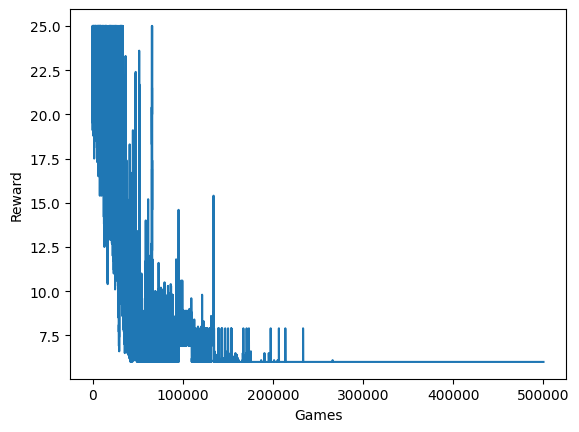

In [90]:
# Calculate and print the average reward per n episodes
n = int(num_episodes/100)
n = 10
rewards_per_thousand_episodes = list(map(lambda x: 10-sum(x)/n, np.split(np.array(rewards_all_episodes), num_episodes/n)))
ind = np.arange(len(rewards_per_thousand_episodes))*n
plt.xlabel("Games")
plt.ylabel("Reward")
plt.plot(ind, rewards_per_thousand_episodes)

In [91]:
rewards_per_thousand_episodes[-10:]

[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]